# 랜덤포레스트

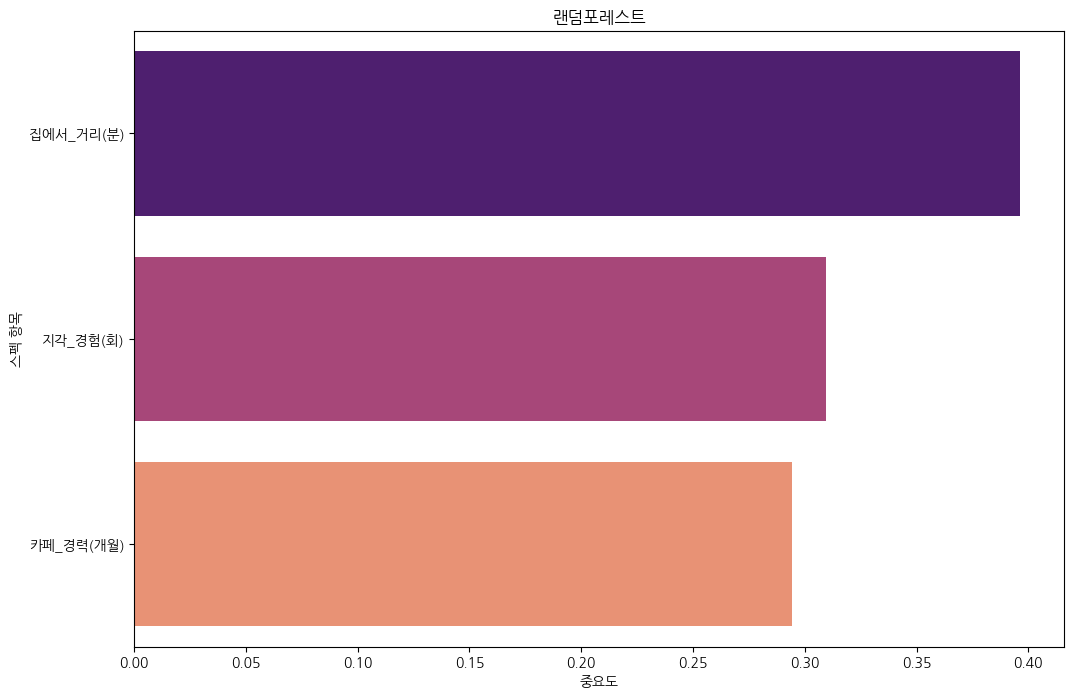

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

data3 = {
    '집에서_거리(분)': [10, 60, 15, 50, 5, 40, 20, 90, 30, 5],
    '카페_경력(개월)': [12, 0, 6, 2, 24, 0, 1, 0, 3, 18],
    '지각_경험(회)': [0, 3, 1, 5, 0, 2, 0, 10, 0, 1],
    '합격여부': ['합격', '불합격', '합격', '불합격', '합격', '불합격', '합격', '불합격', '합격', '합격']
}

df = pd.DataFrame(data3)
x = df[['집에서_거리(분)', '카페_경력(개월)', '지각_경험(회)']]
y = df['합격여부']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x, y)

importances = rf.feature_importances_
df_imp = pd.DataFrame({'스펙 항목': x.columns, '중요도': importances})
df_imp = df_imp.sort_values(by='중요도', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x='중요도', y='스펙 항목', hue='스펙 항목', data=df_imp, palette='magma')
plt.title('랜덤포레스트')
plt.show()

## 데이팅 어플

/opt/conda/lib/python3.11/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


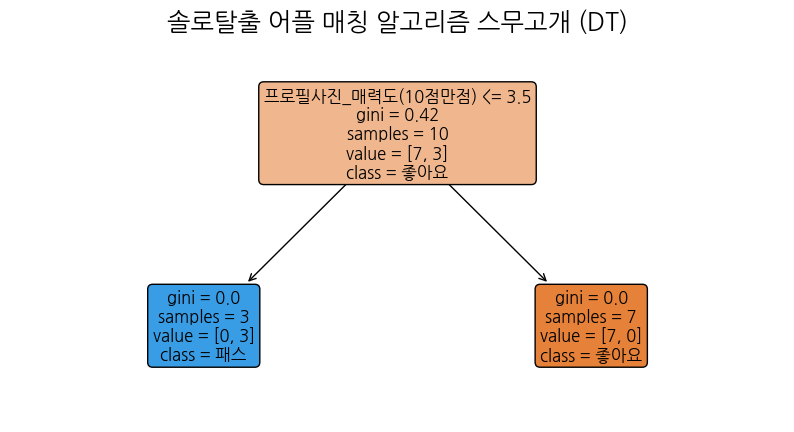

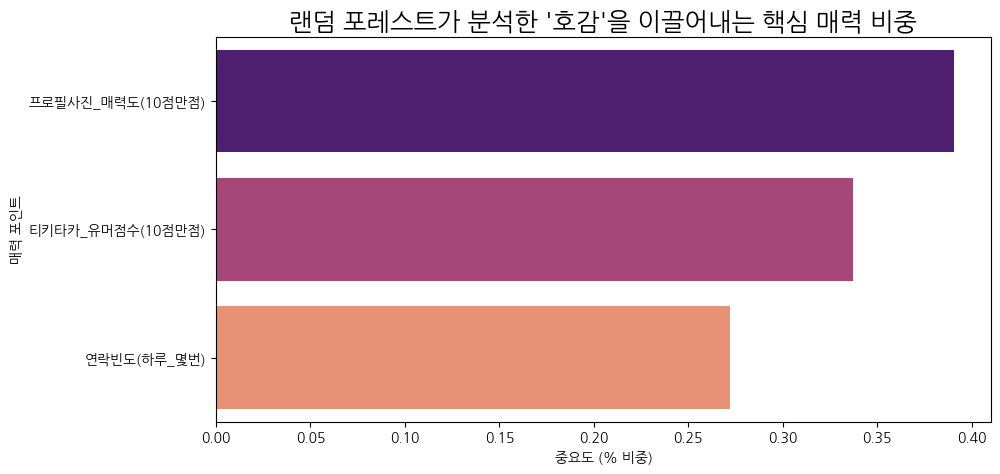

In [13]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

data4 = {
    '연락빈도(하루_몇번)': [1, 10, 20, 2, 5, 0, 15, 30, 2, 8],
    '티키타카_유머점수(10점만점)': [2, 8, 9, 3, 7, 1, 8, 9, 4, 6],
    '프로필사진_매력도(10점만점)': [3, 4, 8, 9, 5, 2, 9, 7, 8, 3],
    '매칭결과': ['패스', '좋아요', '좋아요', '좋아요', '좋아요', '패스', '좋아요', '좋아요', '좋아요', '패스']
}

df = pd.DataFrame(data4)

x = df[['연락빈도(하루_몇번)', '티키타카_유머점수(10점만점)', '프로필사진_매력도(10점만점)']]
y = df[['매칭결과']]

dt_model = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model.fit(x, y)

plt.figure(figsize=(10,5))
plot_tree(
    dt_model,
    feature_names=x.columns,
    class_names = dt_model.classes_,
    filled=True, rounded=True, fontsize=12)

plt.title("솔로탈출 어플 매칭 알고리즘 스무고개 (DT)", fontsize=18)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x, y)

importances = rf.feature_importances_
df_imp = pd.DataFrame({'매력 포인트': x.columns, '중요도 (% 비중)': importances})
df_imp = df_imp.sort_values(by='중요도 (% 비중)', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='중요도 (% 비중)', y='매력 포인트', hue='매력 포인트', data=df_imp, palette='magma')
plt.title("랜덤 포레스트가 분석한 '호감'을 이끌어내는 핵심 매력 비중", fontsize=18)
plt.show()